In [34]:
import matplotlib.pyplot as plt
import numpy as np
from src.quantum_random_walk.quantum_random_walk import noisy_circle_quantum_random_walk_1D, noisy_meas_circle_quantum_random_walk_1D

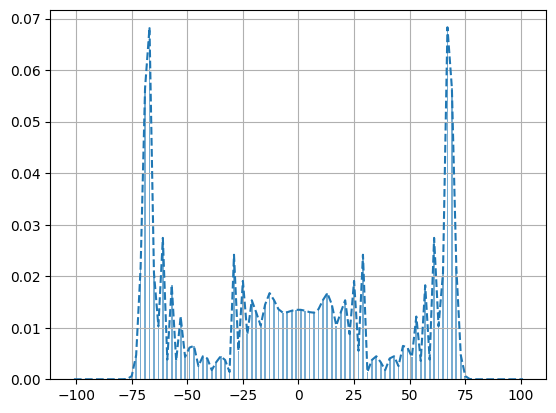

array([-101, -100,  -99,  -98,  -97,  -96,  -95,  -94,  -93,  -92,  -91,
        -90,  -89,  -88,  -87,  -86,  -85,  -84,  -83,  -82,  -81,  -80,
        -79,  -78,  -77,  -76,  -75,  -74,  -73,  -72,  -71,  -70,  -69,
        -68,  -67,  -66,  -65,  -64,  -63,  -62,  -61,  -60,  -59,  -58,
        -57,  -56,  -55,  -54,  -53,  -52,  -51,  -50,  -49,  -48,  -47,
        -46,  -45,  -44,  -43,  -42,  -41,  -40,  -39,  -38,  -37,  -36,
        -35,  -34,  -33,  -32,  -31,  -30,  -29,  -28,  -27,  -26,  -25,
        -24,  -23,  -22,  -21,  -20,  -19,  -18,  -17,  -16,  -15,  -14,
        -13,  -12,  -11,  -10,   -9,   -8,   -7,   -6,   -5,   -4,   -3,
         -2,   -1,    0,    1,    2,    3,    4,    5,    6,    7,    8,
          9,   10,   11,   12,   13,   14,   15,   16,   17,   18,   19,
         20,   21,   22,   23,   24,   25,   26,   27,   28,   29,   30,
         31,   32,   33,   34,   35,   36,   37,   38,   39,   40,   41,
         42,   43,   44,   45,   46,   47,   48,   

In [35]:
max_pos = 101
steps = 100
symm_qrw = True
SEED = 42

for p in [0.01]:
    data, X = noisy_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, 'H', p, SEED)
    Y = data[-1]
    X_odd = X[0::2]
    Y_odd = Y[0::2]
    plt.grid(True, which='major')
    plt.bar(X, Y, alpha=0.6)
    plt.plot(X_odd, Y_odd, '--')
    plt.show()

X

In [36]:
from src.random_walk.random_walk import random_walk

IndexError: list index out of range

Error in callback <function _draw_all_if_interactive at 0x7f3b0aef53a0> (for post_execute), with arguments args (),kwargs {}:


ValueError: x and y must have same first dimension, but have shapes (53,) and (52,)

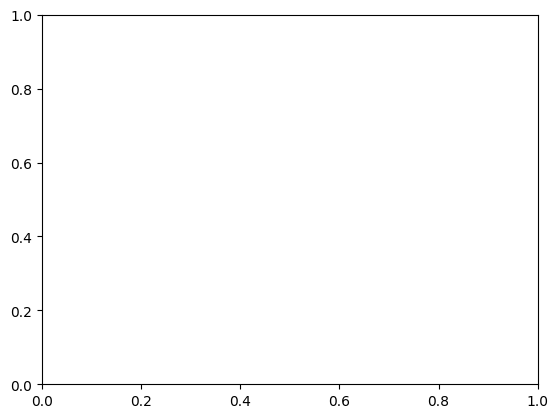

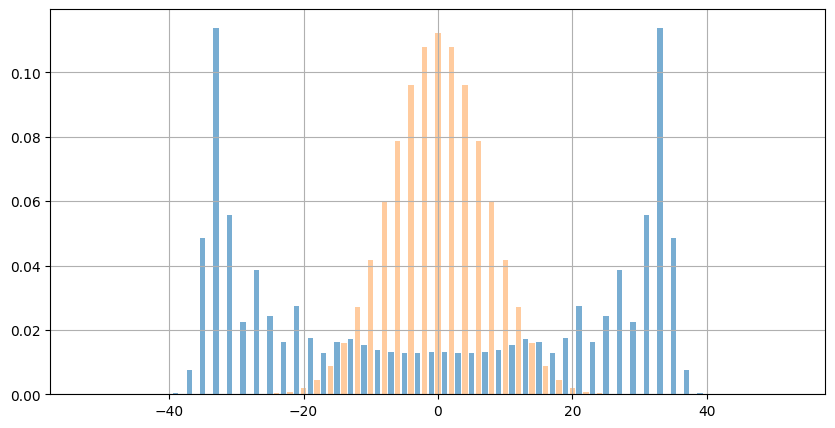

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

max_pos = 52
steps = 50
symm_qrw = True
SEED = 42

probs = np.linspace(0, 1, 100).round(2)

c_Y, _ = random_walk(max_pos, steps, 0.5, 'circular')
cY_odd = c_Y[0::2]
plt.title("")
fig, ax = plt.subplots(figsize=(10, 5))

def update(frame):
    p = probs[frame]

    ax.clear()

    data, X = noisy_circle_quantum_random_walk_1D(
        max_pos,
        steps,
        0.5,
        symm_qrw,
        'X',
        p,
        SEED
    )

    Y = data[-1]

    X_odd = X[0::2]
    Y_odd.ev

    ax.grid(True, which='major')

    ax.bar(X, Y, alpha=0.6, label='quantum')
    ax.bar(X, c_Y, alpha=0.4, label='classical')

    ax.plot(X_odd, Y_odd, '--')
    ax.plot(X_odd, cY_odd, '--')

    ax.set_title(f"X noise quantum walk, p = {p}")
    ax.set_xlabel("Position")
    ax.set_ylabel("Probability")

    ax.legend()

    # utile per evitare che gli assi cambino a ogni frame
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(0, np.max(c_Y) * 1.1)

animation = FuncAnimation(
    fig,
    update,
    frames=len(probs),
    interval=100,   # millisecondi tra frame
    repeat=True
)

animation.save(
    "noisy-X-quantum_vs_classical_walk.gif",
    writer=PillowWriter(fps=10)
)

plt.close(fig)

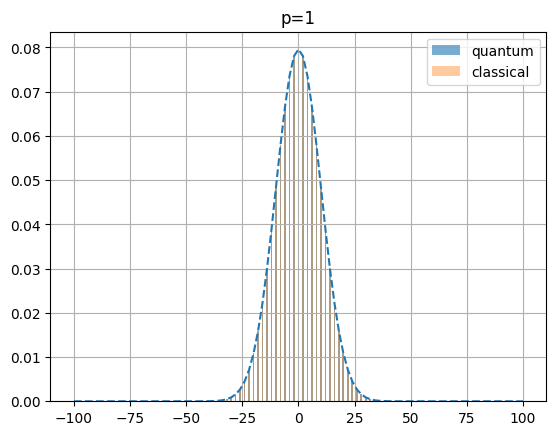

In [38]:
max_pos = 100
steps = 100
symm_qrw = True
SEED = 42
p = 1 # CASO LIMITE : MISURAZIONE PRIMA DI OGNI SHIFT


data, X = noisy_meas_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, p, SEED)
c_Y, _ = random_walk(max_pos, steps, 0.5, 'circular')
Y = data[-1]
X_odd = X[::2]
Y_odd = Y[0::2]
plt.grid(True, which='major')
plt.bar(X, Y, alpha=0.6)
plt.bar(X, c_Y, alpha=0.4)
plt.title(f"p={p}")
plt.legend(['quantum','classical'])
plt.plot(X_odd, Y_odd, '--')
plt.show()